# Model Comparison

Combine the metrics from every approach into a single table and chart:

- TF-IDF + classic ML baseline
- Fine-tuned DistilBERT
- GPT-4o prompt engineering (best strategy)

Each notebook saves its metrics to `../results/`. This notebook loads whatever
is available, so it still runs if a step has not been completed yet.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('..') / 'results'
rows = {}

# Baseline (pick best of the classic models by f1)
p = RESULTS_DIR / 'baseline_metrics.json'
if p.exists():
    baseline = json.loads(p.read_text(encoding='utf-8'))
    best = max(baseline.items(), key=lambda kv: kv[1]['f1'])
    rows['Baseline (' + best[0] + ')'] = {k: best[1][k] for k in ['accuracy', 'precision', 'recall', 'f1']}

p = RESULTS_DIR / 'distilbert_metrics.json'
if p.exists():
    rows['DistilBERT'] = json.loads(p.read_text(encoding='utf-8'))

p = RESULTS_DIR / 'llm_metrics.json'
if p.exists():
    m = json.loads(p.read_text(encoding='utf-8'))
    rows['GPT-4o (' + m.get('strategy', 'llm') + ')'] = {k: m[k] for k in ['accuracy', 'precision', 'recall', 'f1']}

comp = pd.DataFrame(rows).T
print(comp.round(4))

                              accuracy  precision  recall      f1
Baseline (PassiveAggressive)    0.9762     0.9767  0.9788  0.9778
GPT-4o (chain_of_thought)       0.8250     0.7500  1.0000  0.8571


## Comparison chart

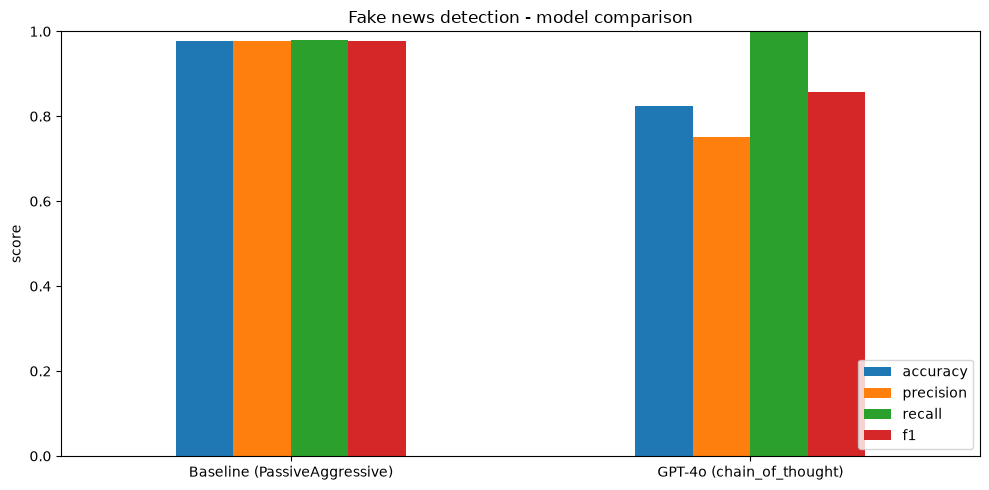

Saved comparison.csv and comparison.png


In [2]:
ax = comp.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.0), rot=0)
ax.set_title('Fake news detection - model comparison')
ax.set_ylabel('score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison.png', dpi=120)
plt.show()

comp.to_csv(RESULTS_DIR / 'comparison.csv')
print('Saved comparison.csv and comparison.png')

## Notes

Use the table above to discuss the trade-offs between the approaches: the
classic baseline is fast and cheap, DistilBERT learns deeper language features,
and the prompt-engineered LLM needs no training but depends on a hosted model.
Write your own interpretation of these numbers in the report.